# Étape 1 : Analyse exploratoire des données (EDA)

**Projet :** Agent de détection d'anomalies et de reporting automatique : TAQA Morocco (DPST)

Objectif de ce notebook : comprendre le **comportement normal** de la tranche simulée avant de construire l'agent de détection. On vérifie aussi visuellement que les anomalies connues du dataset sont bien présentes et cohérentes.

Données : `data/dataset_taqa_synthetique.csv` (18 mois au pas horaire). Les données réelles de TAQA étant confidentielles, ce dataset a été généré à l'aide de l'IA pour reproduire le comportement réaliste d'une tranche de centrale. Il est fourni avec un journal des anomalies qu'il contient (`anomalies_injectees.csv`), qui servira de vérité terrain pour évaluer l'agent de détection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 4)

import os
os.makedirs("../figures", exist_ok=True)

## 1. Chargement et premier aperçu

In [2]:
df = pd.read_csv("../data/dataset_taqa_synthetique.csv", parse_dates=["date"])
print(df.shape)
df.head()

(13104, 15)


,date,puissance_MW,rendement_pct,conso_charbon_t_h,temp_vapeur_C,pression_bar,vibrations_mm_s,debit_eau_t_h,temp_exterieure_C,en_marche,saison,jour_semaine,shift,combustible,age_equipement_annees
0,2025-01-01 00:00:00,334.8,37.99,127.9,536.5,167.8,2.44,996.0,9.3,1,hiver,Wednesday,Q3,charbon,10.59
1,2025-01-01 01:00:00,323.9,38.35,122.0,538.2,165.9,2.52,971.0,8.0,1,hiver,Wednesday,Q3,charbon,10.59
2,2025-01-01 02:00:00,324.4,37.98,124.6,536.9,167.5,2.53,995.0,8.6,1,hiver,Wednesday,Q3,charbon,10.59
3,2025-01-01 03:00:00,334.8,37.92,127.5,538.1,169.6,2.62,1010.0,9.5,1,hiver,Wednesday,Q3,charbon,10.59
4,2025-01-01 04:00:00,329.6,38.20,123.8,539.6,167.3,2.57,1008.0,7.5,1,hiver,Wednesday,Q3,charbon,10.59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   13104 non-null  datetime64[ns]
 1   puissance_MW           13104 non-null  float64       
 2   rendement_pct          13104 non-null  float64       
 3   conso_charbon_t_h      13104 non-null  float64       
 4   temp_vapeur_C          13065 non-null  float64       
 5   pression_bar           13065 non-null  float64       
 6   vibrations_mm_s        13065 non-null  float64       
 7   debit_eau_t_h          13065 non-null  float64       
 8   temp_exterieure_C      13104 non-null  float64       
 9   en_marche              13104 non-null  int64         
 10  saison                 13104 non-null  object        
 11  jour_semaine           13104 non-null  object        
 12  shift                  13104 non-null  object        
 13  c

In [4]:
# Valeurs manquantes : micro-coupures capteurs simulées (~0.3%)
df.isna().sum()[df.isna().sum() > 0]

temp_vapeur_C      39
pression_bar       39
vibrations_mm_s    39
debit_eau_t_h      39
dtype: int64

Les valeurs manquantes ne concernent que les capteurs (température, pression, vibrations, débit), ce qui est réaliste : les compteurs de production sont en général plus fiables. On les traitera par simple exclusion dans les calculs (`dropna`), leur volume est négligeable.

## 2. Statistiques descriptives

On sépare les heures **en marche** des heures d'arrêt, sinon les zéros des arrêts écrasent toutes les statistiques.

In [5]:
marche = df[df["en_marche"] == 1]
print(f"Disponibilité globale : {100 * df['en_marche'].mean():.1f} %")
print(f"Heures en marche : {len(marche)} / {len(df)}")

colonnes_num = ["puissance_MW", "rendement_pct", "conso_charbon_t_h",
                "temp_vapeur_C", "pression_bar", "vibrations_mm_s",
                "debit_eau_t_h", "temp_exterieure_C"]
marche[colonnes_num].describe().round(2).T

Disponibilité globale : 94.0 %
Heures en marche : 12320 / 13104


,count,mean,std,min,25%,50%,75%,max
puissance_MW,12320.0,339.71,9.20,115.60,335.50,340.00,344.50,360.00
rendement_pct,12320.0,37.71,0.49,34.62,37.49,37.76,38.02,38.88
conso_charbon_t_h,12320.0,130.60,4.18,44.40,128.40,130.60,132.90,145.80
temp_vapeur_C,12282.0,538.18,2.61,527.20,536.40,538.20,539.90,569.00
pression_bar,12283.0,167.23,1.31,155.90,166.40,167.20,168.10,182.80
vibrations_mm_s,12283.0,2.71,0.24,1.79,2.59,2.70,2.80,5.20
debit_eau_t_h,12284.0,1036.25,30.61,354.00,1021.00,1037.00,1053.00,1115.00
temp_exterieure_C,12320.0,17.68,5.74,3.80,13.10,17.60,22.20,31.40


Les ordres de grandeur sont conformes à une tranche charbon de ~350 MW :
puissance moyenne ≈ 340 MW, rendement ≈ 37–38 %, conso charbon ≈ 130 t/h, vapeur ≈ 540 °C / 167 bar, vibrations ≈ 2,7 mm/s. Les maxima (vapeur 569 °C, vibrations 5,2 mm/s) correspondent aux anomalies documentées dans le journal : on les retrouvera plus bas.

## 3. Séries temporelles

### 3.1 Puissance produite sur toute la période

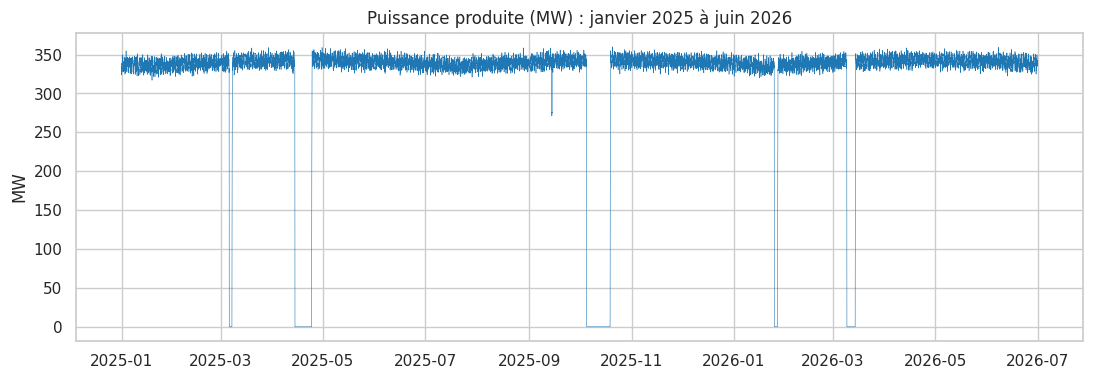

In [6]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["puissance_MW"], lw=0.4, color="tab:blue")
ax.set_title("Puissance produite (MW) : janvier 2025 à juin 2026")
ax.set_ylabel("MW")
plt.savefig("../figures/eda_puissance_globale.png", dpi=120, bbox_inches="tight")
plt.show()

On distingue clairement les **5 arrêts** (retours à zéro) : 2 arrêts forcés courts (mars 2025, janvier 2026) et 3 arrêts planifiés plus longs (avril 2025, octobre 2025, mars 2026). Le reste du temps, la tranche tourne proche de sa charge nominale.

### 3.2 Zoom sur 2 semaines : cycle jour/nuit

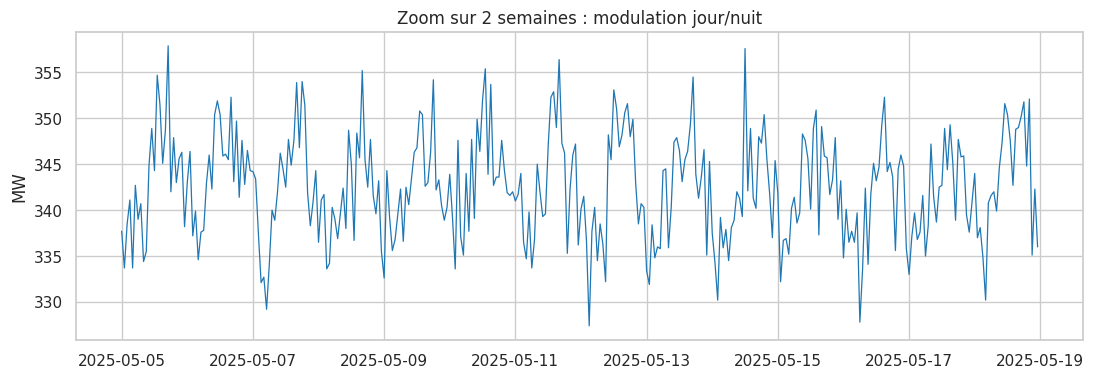

In [7]:
zoom = df[(df["date"] >= "2025-05-05") & (df["date"] < "2025-05-19")]
fig, ax = plt.subplots()
ax.plot(zoom["date"], zoom["puissance_MW"], lw=0.9, color="tab:blue")
ax.set_title("Zoom sur 2 semaines : modulation jour/nuit")
ax.set_ylabel("MW")
plt.show()

### 3.3 Rendement thermique : deux dérives visibles

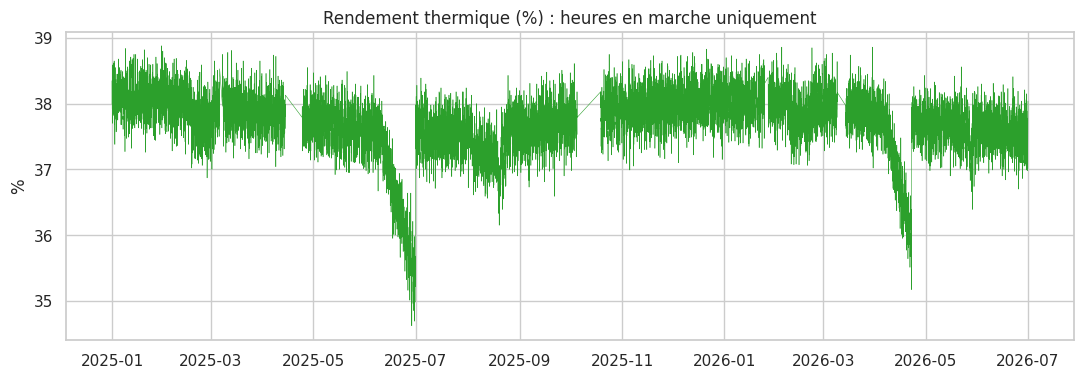

In [8]:
fig, ax = plt.subplots()
ax.plot(marche["date"], marche["rendement_pct"], lw=0.4, color="tab:green")
ax.set_title("Rendement thermique (%) : heures en marche uniquement")
ax.set_ylabel("%")
plt.savefig("../figures/eda_rendement.png", dpi=120, bbox_inches="tight")
plt.show()

Deux **baisses progressives du rendement** apparaissent (juin 2025 et avril 2026) : ce sont des épisodes d'encrassement chaudière, corrigés ensuite par un nettoyage (visible dans `historique_maintenance.csv`). C'est typiquement le genre de dérive lente qu'un suivi manuel détecte tard.

### 3.4 Vibrations turbine : dérives avant pannes

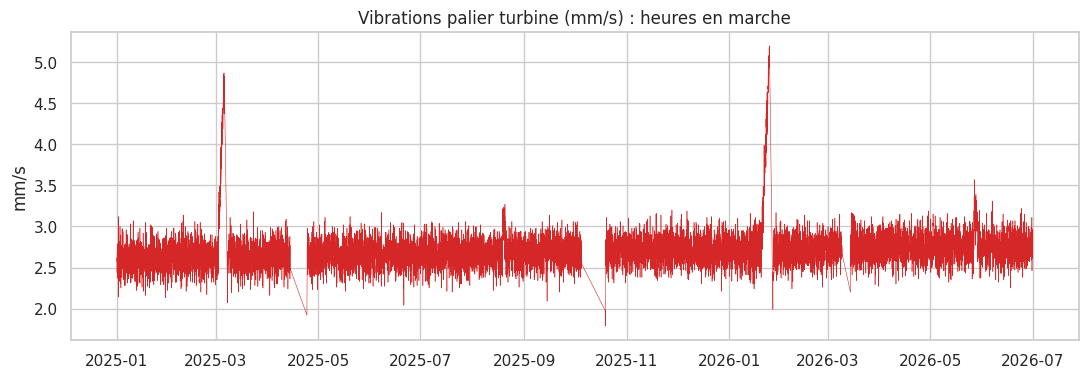

In [9]:
fig, ax = plt.subplots()
ax.plot(marche["date"], marche["vibrations_mm_s"], lw=0.4, color="tab:red")
ax.set_title("Vibrations palier turbine (mm/s) : heures en marche")
ax.set_ylabel("mm/s")
plt.savefig("../figures/eda_vibrations.png", dpi=120, bbox_inches="tight")
plt.show()

Les deux pointes (mars 2025 et janvier 2026) sont les **dérives progressives avant arrêt forcé** : les vibrations montent de ~2,7 à ~5 mm/s en 4–5 jours, puis la tranche déclenche. On note aussi une très légère tendance de fond à la hausse (vieillissement simulé de la machine).

## 4. Validation visuelle des anomalies connues

Le journal `anomalies_injectees.csv`, fourni avec le dataset, liste les 11 anomalies présentes (notre vérité terrain). On en vérifie deux visuellement.

In [10]:
journal = pd.read_csv("../data/anomalies_injectees.csv", parse_dates=["date_debut", "date_fin"])
journal[["id", "type_anomalie", "variables_concernees", "date_debut", "date_fin"]]

,id,type_anomalie,variables_concernees,date_debut,date_fin
0,A02,pic_ponctuel,temp_vapeur_C,2025-02-11 14:00:00,2025-02-11 17:00:00
1,A01,derive_progressive,vibrations_mm_s,2025-03-02 04:00:00,2025-03-06 04:00
2,A03,baisse_rendement,rendement_pct,2025-06-10 00:00:00,2025-06-30 20:00:00
3,A04,pic_ponctuel,pression_bar,2025-07-22 09:00:00,2025-07-22 11:00:00
4,A05,multivariee,vibrations_mm_s|temp_vapeur_C|rendement_pct,2025-08-19 00:00:00,2025-08-20 12:00:00
5,A06,chute_puissance,puissance_MW,2025-09-14 11:00:00,2025-09-14 16:00
6,A07,pic_ponctuel,temp_vapeur_C,2025-12-03 21:00:00,2025-12-04 01:00:00
7,A08,derive_progressive,vibrations_mm_s,2026-01-20 02:00:00,2026-01-25 02:00
8,A09,baisse_rendement,rendement_pct,2026-04-06 00:00:00,2026-04-22 16:00:00
9,A10,multivariee,vibrations_mm_s|temp_vapeur_C|rendement_pct,2026-05-27 00:00:00,2026-05-29 00:00:00


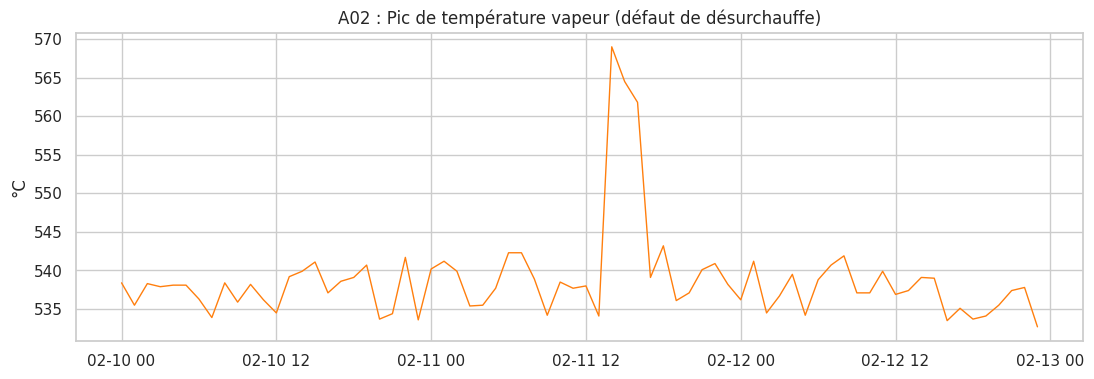

In [11]:
# A02 : pic ponctuel de température vapeur (11/02/2025)
zoom = df[(df["date"] >= "2025-02-10") & (df["date"] < "2025-02-13")]
fig, ax = plt.subplots()
ax.plot(zoom["date"], zoom["temp_vapeur_C"], lw=1, color="tab:orange")
ax.set_title("A02 : Pic de température vapeur (défaut de désurchauffe)")
ax.set_ylabel("°C")
plt.show()

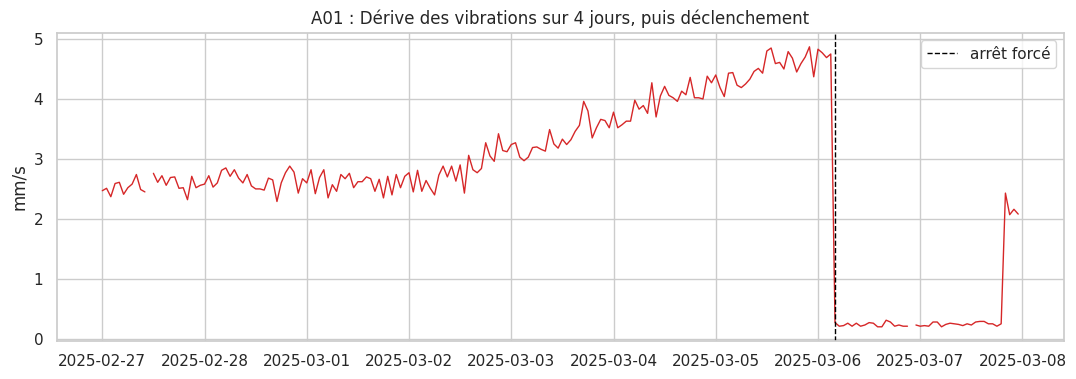

In [12]:
# A01 : dérive progressive des vibrations avant l'arrêt forcé du 06/03/2025
zoom = df[(df["date"] >= "2025-02-27") & (df["date"] < "2025-03-08")]
fig, ax = plt.subplots()
ax.plot(zoom["date"], zoom["vibrations_mm_s"], lw=1, color="tab:red")
ax.axvline(pd.Timestamp("2025-03-06 04:00"), color="black", ls="--", lw=1, label="arrêt forcé")
ax.set_title("A01 : Dérive des vibrations sur 4 jours, puis déclenchement")
ax.set_ylabel("mm/s")
ax.legend()
plt.savefig("../figures/eda_derive_A01.png", dpi=120, bbox_inches="tight")
plt.show()

Le scénario est réaliste : une montée lente, bien au-dessus du bruit, qui aurait pu être détectée **plusieurs jours avant la panne** : c'est exactement la valeur ajoutée attendue de l'agent de détection.

À l'inverse, les anomalies **multivariées** (A05, A10) sont invisibles à l'œil nu sur une courbe : chaque variable reste dans sa plage normale, seule la combinaison est anormale. Vérifions.

In [13]:
# A05 : anomalie multivariée du 19-20/08/2025 : chaque variable reste "normale"
a05 = marche[(marche["date"] >= "2025-08-19") & (marche["date"] < "2025-08-20")]
ref = marche[colonnes_num]
comparaison = pd.DataFrame({
    "moyenne_normale": ref[["vibrations_mm_s", "temp_vapeur_C", "rendement_pct"]].mean(),
    "ecart_type": ref[["vibrations_mm_s", "temp_vapeur_C", "rendement_pct"]].std(),
    "pendant_A05": a05[["vibrations_mm_s", "temp_vapeur_C", "rendement_pct"]].mean(),
}).round(2)
comparaison["z_score_approx"] = ((comparaison["pendant_A05"] - comparaison["moyenne_normale"])
                                 / comparaison["ecart_type"]).round(1)
comparaison

,moyenne_normale,ecart_type,pendant_A05,z_score_approx
vibrations_mm_s,2.71,0.24,3.01,1.2
temp_vapeur_C,538.18,2.61,542.50,1.7
rendement_pct,37.71,0.49,36.77,-1.9


Pendant A05, chaque variable ne s'écarte que de **1 à 2 écarts-types** : trop peu pour déclencher un seuil à 3σ. Un simple z-score ne verra rien : c'est le cas d'usage qui justifie la couche Machine Learning (Isolation Forest) de l'agent de détection.

## 5. Corrélations entre variables

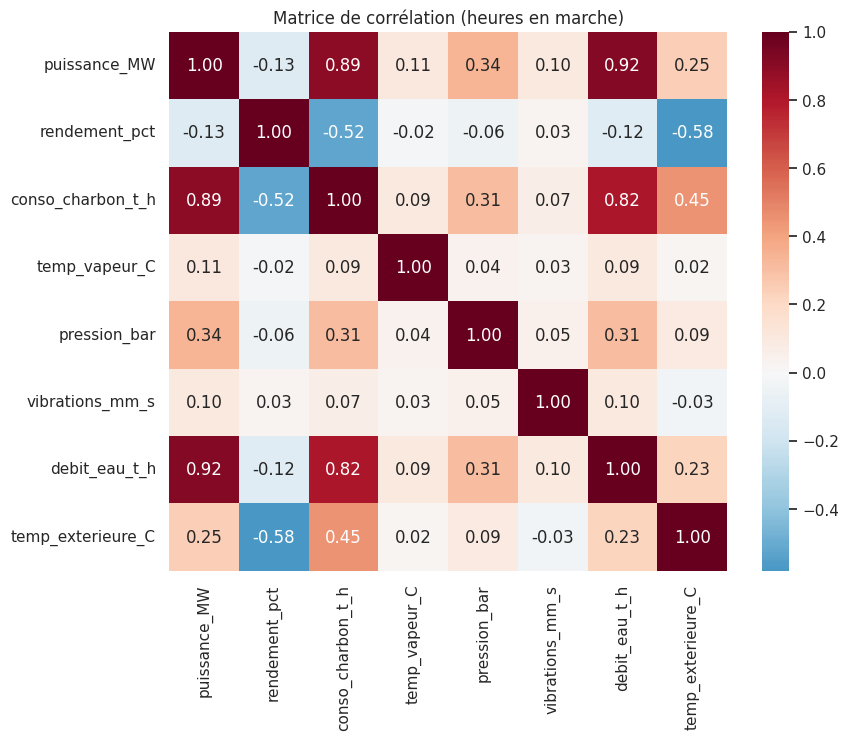

In [14]:
corr = marche[colonnes_num].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Matrice de corrélation (heures en marche)")
plt.savefig("../figures/eda_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

Corrélations conformes à la physique du procédé :

- **puissance ↔ conso charbon (≈ 0,9)** et **puissance ↔ débit d'eau (≈ 0,9)** : plus on produit, plus on brûle de charbon et plus on fait circuler d'eau ;
- corrélations plus faibles mais positives avec la pression et la température vapeur (régulation autour d'une consigne) ;
- rendement légèrement corrélé négativement à la température extérieure (effet condenseur).

Ces liens entre variables sont exactement ce que l'Isolation Forest exploitera pour repérer les combinaisons anormales.

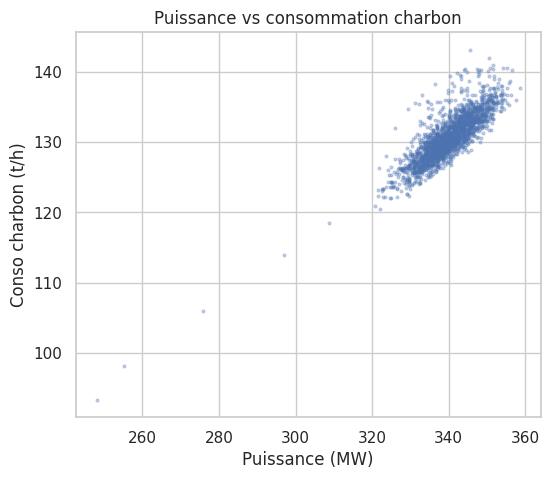

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ech = marche.sample(2000, random_state=1)
ax.scatter(ech["puissance_MW"], ech["conso_charbon_t_h"], s=4, alpha=0.3)
ax.set_xlabel("Puissance (MW)")
ax.set_ylabel("Conso charbon (t/h)")
ax.set_title("Puissance vs consommation charbon")
plt.show()

## 6. Effets de contexte (saison, heure, shift)

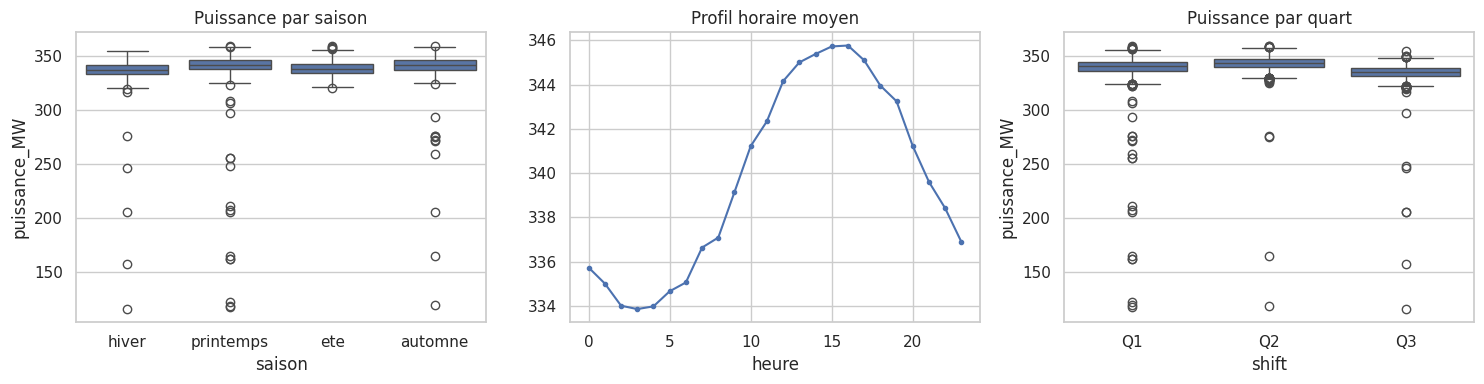

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=marche, x="saison", y="puissance_MW",
            order=["hiver", "printemps", "ete", "automne"], ax=axes[0])
axes[0].set_title("Puissance par saison")
profil = marche.groupby(marche["date"].dt.hour)["puissance_MW"].mean()
axes[1].plot(profil.index, profil.values, marker="o", ms=3)
axes[1].set_title("Profil horaire moyen")
axes[1].set_xlabel("heure")
sns.boxplot(data=marche, x="shift", y="puissance_MW", order=["Q1", "Q2", "Q3"], ax=axes[2])
axes[2].set_title("Puissance par quart")
plt.tight_layout()
plt.savefig("../figures/eda_contexte.png", dpi=120, bbox_inches="tight")
plt.show()

On retrouve la légère saisonnalité (pointes été/hiver), le creux nocturne dans le profil horaire, et logiquement une puissance un peu plus basse pour le quart de nuit Q3.

## 7. Conclusions de l'EDA

1. Le dataset est **cohérent et réaliste** : ordres de grandeur corrects, corrélations physiques respectées, disponibilité de 94 %.
2. Le **comportement normal** est bien caractérisé : puissance 340 ± 9 MW, rendement 37,7 ± 0,5 %, vibrations 2,7 ± 0,25 mm/s. Ces références serviront à calibrer les seuils statistiques.
3. Les anomalies **univariées** (pics, dérives fortes) sont visibles et détectables par z-score.
4. Les anomalies **multivariées** (A05, A10) sont indétectables variable par variable (écarts ≤ 2σ) → justification de la couche **Isolation Forest**.